In [1]:
import os 
os.chdir(r'C:\Users\rajja\Documents\Synent Project\Task3_Netflix')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv("netflix_titles.csv")   #load thye csv file into datraframe

In [4]:
df.shape  #To check how many rows and columns

(8807, 12)

In [5]:
df.head() #First 5 rows

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
df.info() # To check information of a dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df.isnull().sum() # To check how many null values here

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
df['director'].fillna('Unknown',inplace=True)
df['cast'].fillna('Unknown',inplace=True)
df['country'].fillna('Unknown',inplace=True)
df['date_added'].fillna('Unknown',inplace=True)
df['duration'].fillna('Unknown',inplace=True)
df['rating'].fillna(df['rating'].mode()[0],inplace=True)  # Fill null values with another values

C:\Users\rajja\AppData\Local\Temp\ipykernel_9048\2708688373.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown',inplace=True)
C:\Users\rajja\AppData\Local\Temp\ipykernel_9048\2708688373.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

In [9]:
df.isnull().sum() #After filling values whats the status

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [10]:
df.duplicated().sum() # to check how mant duplicate here

np.int64(0)

In [11]:
df.dropna(subset=['date_added'], inplace=True)  #Drop null date from column 
df['date_added'] = pd.to_datetime(df['date_added'],errors='coerce') #Change the datatype of date_added

In [12]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [13]:
df['type'].value_counts() #How many values inside the type column

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [14]:
df['country'].value_counts() #how many country 

country
United States                             2818
India                                      972
Unknown                                    831
United Kingdom                             419
Japan                                      245
                                          ... 
Romania, Bulgaria, Hungary                   1
Uruguay, Guatemala                           1
France, Senegal, Belgium                     1
Mexico, United States, Spain, Colombia       1
United Arab Emirates, Jordan                 1
Name: count, Length: 749, dtype: int64

Text(0.5, 1.0, 'Movie Show vs Tv show')

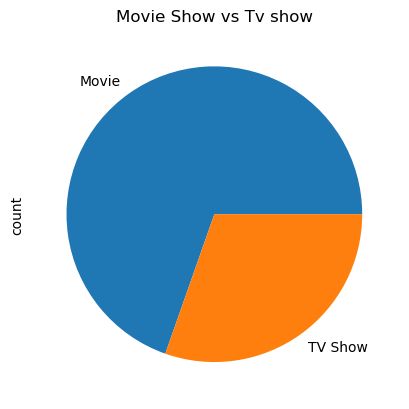

In [15]:
df['type'].value_counts().plot(kind='pie')
plt.title('Movie Show vs Tv show')

Text(0.5, 1.0, 'Top 10 Country with Content')

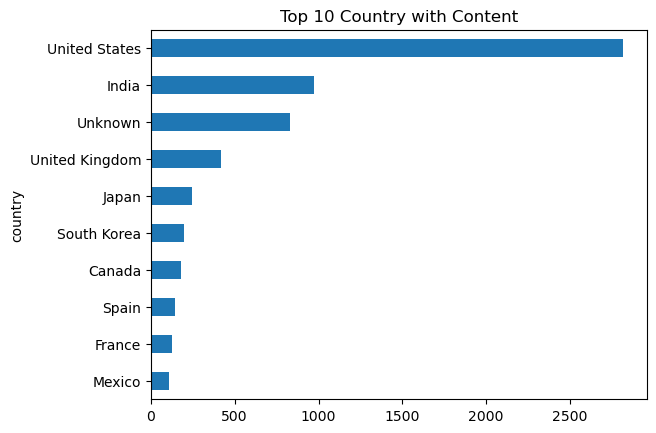

In [16]:
df['country'].value_counts().head(10).sort_values().plot(kind='barh')
plt.title("Top 10 Country with Content")

Text(0.5, 1.0, 'Top 10 Genres')

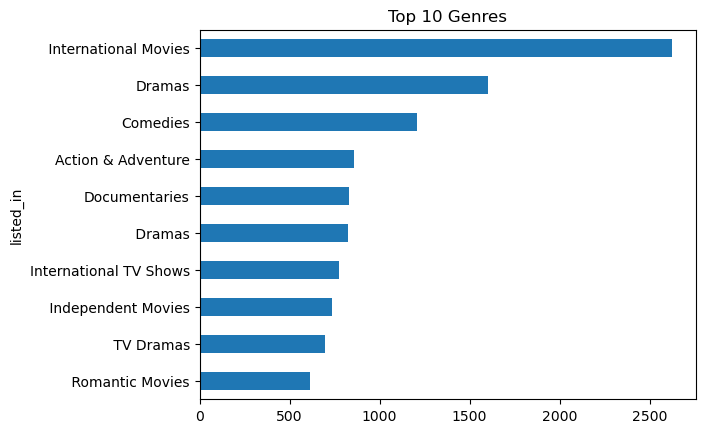

In [17]:
genres=df['listed_in'].str.split(',').explode()
genres.value_counts().head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Genres")

In [18]:
df['rating'].value_counts()  #How many values in rating 

rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

<Axes: ylabel='rating'>

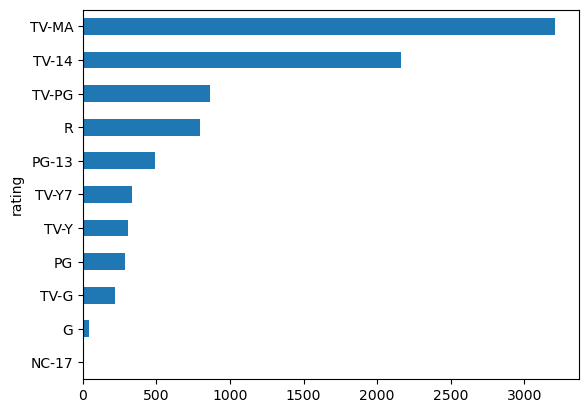

In [19]:
valid_ratings = ['G', 'PG', 'PG-13', 'R', 'NC-17', 
                 'TV-Y', 'TV-Y7', 'TV-G', 'TV-PG', 
                 'TV-14', 'TV-MA']     #Only usebale rating in valid rating

df = df[df['rating'].isin(valid_ratings)]
df['rating'].value_counts().sort_values().plot(kind='barh')

(2000.0, 2023.0)

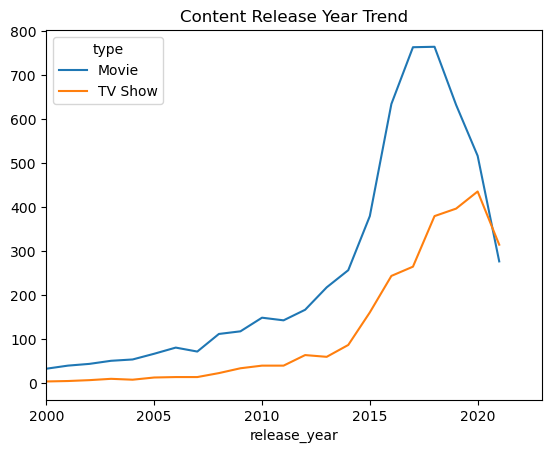

In [29]:
df.groupby('release_year')['type'].value_counts().unstack().plot()
plt.title("Content Release Year Trend")
plt.xlim(2000, 2023)

In [34]:
print(f'Total Titles: {len(df)}')
print(f'Total Movies: {len(df[df["type"] == "Movie"])}')
print(f'Total TV Shows: {len(df[df["type"] == "TV Show"])}')
print(f'Most Common Rating: {df["rating"].mode()[0]}')
print(f'Top Country: {df["country"].value_counts().index[0]}')
print(f'Top Genre: {genres.value_counts().index[0]}')
print(f'Most Content Release Year: {int(df["release_year"].mode()[0])}')  

Total Titles: 8715
Total Movies: 6045
Total TV Shows: 2670
Most Common Rating: TV-MA
Top Country: United States
Top Genre:  International Movies
Most Content Release Year: 2018


In [37]:
df.to_csv("Netflix_cleaned.csv",index="False")   # To save the csv file 